In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [2]:
# 1. Data Validation Ingestion Gate
input_file = "master_feature_table_with_hazards.csv"
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Missing master database file! Please verify 'master_feature_table_with_hazards.csv' is in your directory.")

df = pd.read_csv(input_file)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18260 entries, 0 to 18259
Data columns (total 67 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   location                        18260 non-null  str    
 1   date                            18260 non-null  str    
 2   temp_max                        18260 non-null  float64
 3   temp_min                        18260 non-null  float64
 4   precipitation                   18260 non-null  float64
 5   rain                            18260 non-null  float64
 6   snowfall                        18260 non-null  float64
 7   wind_speed                      18260 non-null  float64
 8   temperature_range               18260 non-null  float64
 9   heavy_rain_flag                 18260 non-null  int64  
 10  snow_flag                       18260 non-null  int64  
 11  strong_wind_flag                18260 non-null  int64  
 12  location_id                     18260 non-n

In [4]:
out=['risk_percentile','risk_category']
for c in out:
    dfff=df[c].value_counts()
    print(dfff)

risk_percentile
32.35    25
31.91    20
31.19    19
34.13    17
18.59    16
         ..
60.42     1
63.05     1
57.19     1
53.73     1
42.74     1
Name: count, Length: 7351, dtype: int64
risk_category
Moderate    9913
Low         8304
High          43
Name: count, dtype: int64


In [5]:
# 2. Phase 3: High-Alpha Feature Selection (Matched exactly to your CSV columns)
# Keeping ONLY raw environmental, terrain, human logistics, and transport variables.
feature_columns = [
    'rain', 'snowfall', 'wind_speed', 'temp_max', 'precipitation',
    'elevation', 'mountain_flag', 'coastal_flag', 'high_altitude_flag',
    'nearest_landslide_km', 'landslide_density_per_1000sqkm',
    'crowd_baseline', 'festival_boost', 'school_vacation_flag', 'long_weekend_flag', 'is_weekend',
    'transport_complexity_score', 'budget_stress_index', 'elevation_penalty'
]
len(feature_columns)

19

In [6]:
# Separate independent features (X) and target variable (y)
X = df[feature_columns].astype(float)
y = df['overall_hazard_score'].astype(float)

In [7]:
print("=====================================================================")
print("📊 NOTEBOOK 08A - CELL 1: FOCUS FEATURES AUDIT REPORT")
print("=====================================================================")
print(f" -> Total Historical Row Records      : {X.shape[0]}")
print(f" -> Missing Values in Input Features   : {X.isnull().sum().sum()}")
print(f" -> Missing Values in Target (y)      : {y.isnull().sum()}")
print(f" -> Duplicate Records in Feature Space: {X.duplicated().sum()}")

📊 NOTEBOOK 08A - CELL 1: FOCUS FEATURES AUDIT REPORT
 -> Total Historical Row Records      : 18260
 -> Missing Values in Input Features   : 0
 -> Missing Values in Target (y)      : 0
 -> Duplicate Records in Feature Space: 111


In [8]:
# 3. Phase 4: Train/Test Split (80/20 Hold-Out Configuration)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n=====================================================================")
print("🧬 PHASE 4: TRAINING MATRICES LOCKDOWN")
print("=====================================================================")
print(f" -> Training Feature Subset (X_train) Shape: {X_train.shape[0]} rows x {X_train.shape[1]} columns")
print(f" -> Testing Feature Subset  (X_test)  Shape: {X_test.shape[0]} rows x {X_test.shape[1]} columns")
print("=====================================================================")


🧬 PHASE 4: TRAINING MATRICES LOCKDOWN
 -> Training Feature Subset (X_train) Shape: 14608 rows x 19 columns
 -> Testing Feature Subset  (X_test)  Shape: 3652 rows x 19 columns


In [9]:
print(y_train.shape,y_test.shape)


(14608,) (3652,)


## Models Tournament & 5-Fold Cross-Validation (Phases 5, 6, & 7)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

In [11]:
# 1. Phase 5: Initialize Baseline and Advanced Model Suite
# Check if XGBoost is available in the active environment
try:
    from xgboost import XGBRegressor
    xgb_available = True
    print("🚀 XGBoost framework library discovered and activated inside the framework workspace.")
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost package not found. Continuing suite evaluation with Linear and Random Forest models.")

model_pool = {
    "Linear Regression Baseline": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

if xgb_available:
    model_pool["XGBoost Regressor"] = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

🚀 XGBoost framework library discovered and activated inside the framework workspace.


In [12]:
# 2. Phases 6 & 7: Model Tournament Evaluation & 5-Fold Cross-Validation Loop
evaluation_records = []
trained_models = {}

print("\n--- INITIATING PERFORMANCE TOURNAMENT & CROSS-VALIDATION CYCLES ---")
for label, model_obj in model_pool.items():
    print(f" -> Currently Training: {label}...")
    
    # Train model on the 80% training set split
    model_obj.fit(X_train, y_train)
    trained_models[label] = model_obj
    
    # Generate test predictions over the 20% hold-out evaluation set
    predictions = model_obj.predict(X_test)
    
    # Compute standard regression metrics
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    # Execute 5-Fold Cross Validation over the training partition to test structural stability
    print(f"    Running 5-Fold Cross-Validation for {label}...")
    cv_scores = cross_val_score(model_obj, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    
    evaluation_records.append({
        "Model Candidate": label,
        "Test R² Score": round(r2, 4),
        "Mean CV R² Score": round(cv_scores.mean(), 4),
        "CV R² Std Dev": round(cv_scores.std(), 4),
        "Test MAE": round(mae, 4),
        "Test RMSE": round(rmse, 4)
    })


--- INITIATING PERFORMANCE TOURNAMENT & CROSS-VALIDATION CYCLES ---
 -> Currently Training: Linear Regression Baseline...
    Running 5-Fold Cross-Validation for Linear Regression Baseline...
 -> Currently Training: Random Forest Regressor...
    Running 5-Fold Cross-Validation for Random Forest Regressor...
 -> Currently Training: XGBoost Regressor...
    Running 5-Fold Cross-Validation for XGBoost Regressor...


In [13]:
# 3. Phase 6: Compile and Save the Final Experimental Comparison Leaderboard
df_leaderboard = pd.DataFrame(evaluation_records).sort_values(by="Test R² Score", ascending=False).reset_index(drop=True)
df_leaderboard.to_csv("model_comparison_leaderboard.csv", index=False)

print("\n=====================================================================")
print("🏆 TOURNAMENT COMPLETED: EXPERIMENTAL COMPARISON LEADERBOARD")
print("=====================================================================")
print(df_leaderboard.to_string(index=False))
print("=====================================================================")


🏆 TOURNAMENT COMPLETED: EXPERIMENTAL COMPARISON LEADERBOARD
           Model Candidate  Test R² Score  Mean CV R² Score  CV R² Std Dev  Test MAE  Test RMSE
         XGBoost Regressor         0.9988            0.9988         0.0002    0.1303     0.2414
   Random Forest Regressor         0.9978            0.9974         0.0004    0.1278     0.3370
Linear Regression Baseline         0.9750            0.9603         0.0165    0.6159     1.1259


## Native Feature Importance Audit (Phase 10 Baseline)

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [15]:
# 1. Extract feature importance matrices from the winning Random Forest model object
winning_model_label = df_leaderboard.iloc[0]["Model Candidate"]
champion_model = trained_models[winning_model_label]

importances = champion_model.feature_importances_
indices = np.argsort(importances)

In [16]:
# 2. Structure into a clean analytics DataFrame for verification
df_importances = pd.DataFrame({
    'Feature Name': [feature_columns[i] for i in indices],
    'MDI Importance Score': [importances[i] for i in indices]
})

print("=====================================================================")
print("📊 NOTEBOOK 08A - CELL 3: NATIVE FEATURE IMPORTANCE SUMMARY")
print("=====================================================================")
print(df_importances.sort_values(by='MDI Importance Score', ascending=False).to_string(index=False))

📊 NOTEBOOK 08A - CELL 3: NATIVE FEATURE IMPORTANCE SUMMARY
                  Feature Name  MDI Importance Score
                     elevation              0.567453
                 precipitation              0.128899
                crowd_baseline              0.119748
          nearest_landslide_km              0.071485
                          rain              0.052751
          school_vacation_flag              0.049044
                    wind_speed              0.002993
                      temp_max              0.002593
                    is_weekend              0.002259
                festival_boost              0.001652
                      snowfall              0.000631
landslide_density_per_1000sqkm              0.000415
             long_weekend_flag              0.000078
                 mountain_flag              0.000000
                  coastal_flag              0.000000
            high_altitude_flag              0.000000
           budget_stress_index          

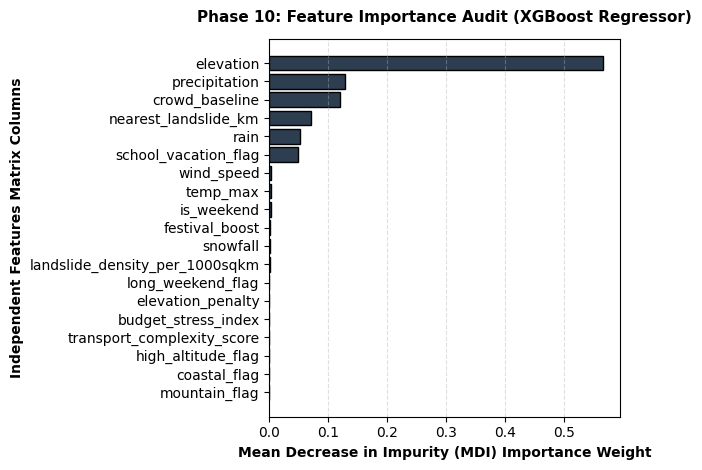

In [17]:
# 3. Render the horizontal feature ranking plot cleanly (No .figure() used)
plt.barh(df_importances['Feature Name'], df_importances['MDI Importance Score'], color="#2C3E50", edgecolor="black")

plt.xlabel("Mean Decrease in Impurity (MDI) Importance Weight", fontsize=10, fontweight="bold")
plt.ylabel("Independent Features Matrix Columns", fontsize=10, fontweight="bold")
plt.title(f"Phase 10: Feature Importance Audit ({winning_model_label})", fontsize=11, fontweight="bold", pad=12)
plt.grid(True, linestyle="--", alpha=0.4, axis="x")

plt.tight_layout()
output_importance_png = "ml_feature_importances.png"
plt.savefig(output_importance_png, dpi=300)

## Error & Residual Analysis Diagnostic Suite

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
# 1. Isolate the winning model from your leaderboard dataframe
winning_model_label = df_leaderboard.iloc[0]["Model Candidate"]
champion_model = trained_models[winning_model_label]

In [20]:
# 2. Generate model predictions over the unseen hold-out test set
final_predictions = champion_model.predict(X_test)
errors_residuals = y_test - final_predictions

In [21]:
print("=====================================================================")
print("📊 NOTEBOOK 08A - CELL 4: RESIDUAL & ERROR BIAS ANALYSIS")
print("=====================================================================")
print(f" -> Winning Model Evaluated      : {winning_model_label}")
print(f" -> Mean Absolute Error (MAE)    : {round(np.mean(np.abs(errors_residuals)), 4)} points")
print(f" -> Residual Maximum Under-pred  : {round(np.max(errors_residuals), 4)} points")
print(f" -> Residual Maximum Over-pred   : {round(np.min(errors_residuals), 4)} points")

📊 NOTEBOOK 08A - CELL 4: RESIDUAL & ERROR BIAS ANALYSIS
 -> Winning Model Evaluated      : XGBoost Regressor
 -> Mean Absolute Error (MAE)    : 0.1303 points
 -> Residual Maximum Under-pred  : 3.5698 points
 -> Residual Maximum Over-pred   : -2.1229 points


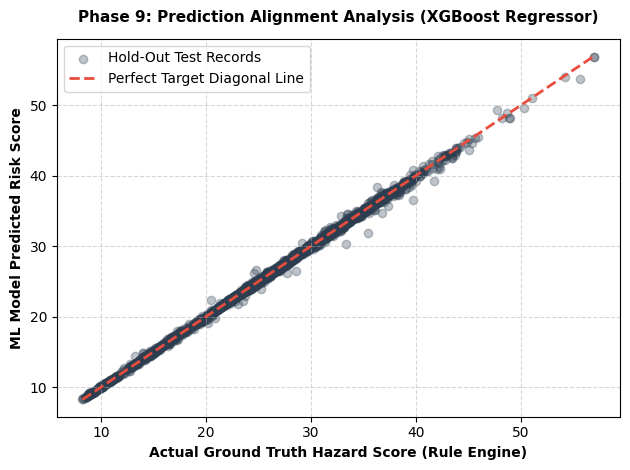

In [22]:
# 3. Render Diagram A: Actual vs Predicted Scatter (Clean layout, no .figure() used)
plt.scatter(y_test, final_predictions, color="#2C3E50", alpha=0.3, label="Hold-Out Test Records")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#E74C3C", linestyle="--", lw=2, label="Perfect Target Diagonal Line")

plt.xlabel("Actual Ground Truth Hazard Score (Rule Engine)", fontsize=10, fontweight="bold")
plt.ylabel("ML Model Predicted Risk Score", fontsize=10, fontweight="bold")
plt.title(f"Phase 9: Prediction Alignment Analysis ({winning_model_label})", fontsize=11, fontweight="bold", pad=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
output_scatter_png = "ml_actual_vs_predicted.png"
plt.savefig(output_scatter_png, dpi=300)
plt.show()

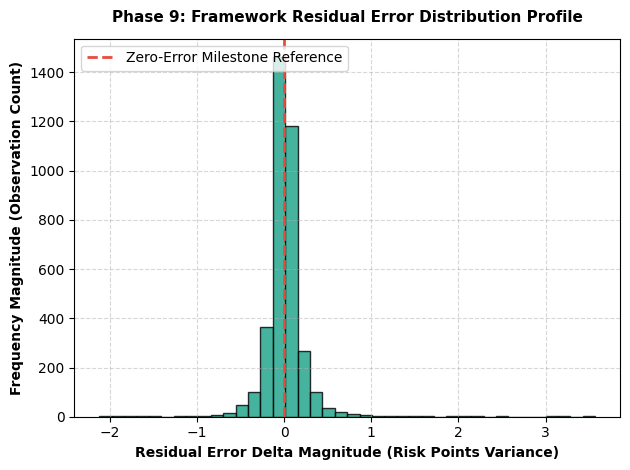

In [23]:
# 4. Render Diagram B: Residual Distribution Profile Histogram
plt.hist(errors_residuals, bins=40, color="#16A085", edgecolor="black", alpha=0.8)
plt.axvline(0, color="#E74C3C", linestyle="--", lw=2, label="Zero-Error Milestone Reference")

plt.xlabel("Residual Error Delta Magnitude (Risk Points Variance)", fontsize=10, fontweight="bold")
plt.ylabel("Frequency Magnitude (Observation Count)", fontsize=10, fontweight="bold")
plt.title("Phase 9: Framework Residual Error Distribution Profile", fontsize=11, fontweight="bold", pad=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
output_residual_png = "ml_residual_distribution.png"
plt.savefig(output_residual_png, dpi=300)
plt.show()

## Model Serialization & Schema Export Gate

In [24]:
import joblib
import os

In [25]:
print("=====================================================================")
print("💾 PHASE 11: PRODUCTION ARTIFACT SERIALIZATION GATEWAY")
print("=====================================================================")

# Define explicit model file target destination parameters
model_output_filename = "travel_risk_model.pkl"
schema_output_filename = "model_feature_schema.pkl"

💾 PHASE 11: PRODUCTION ARTIFACT SERIALIZATION GATEWAY


In [26]:
# 1. Freeze and write the optimized champion regressor to a binary file
joblib.dump(champion_model, model_output_filename)

['travel_risk_model.pkl']

In [27]:
# 2. Save the exact ordered list of columns the model expects
joblib.dump(feature_columns, schema_output_filename)

['model_feature_schema.pkl']

In [28]:
# 3. Structural verification gate
if os.path.exists(model_output_filename) and os.path.exists(schema_output_filename):
    print(f" ✅ SUCCESS: Optimized model binary payload exported to: '{model_output_filename}'")
    print(f" ✅ SUCCESS: Structural feature sequence mapping written to: '{schema_output_filename}'")
    print(f" -> Feature Array Length Saved: {len(feature_columns)} columns")
else:
    print(" ❌ Error: Serialization failed. Please check workspace folder write permissions.")
print("=====================================================================")

 ✅ SUCCESS: Optimized model binary payload exported to: 'travel_risk_model.pkl'
 ✅ SUCCESS: Structural feature sequence mapping written to: 'model_feature_schema.pkl'
 -> Feature Array Length Saved: 19 columns


🏁 NOTEBOOK 08A CLOSING ENHANCEMENTS: STRUCTURAL CORRELATION AUDIT


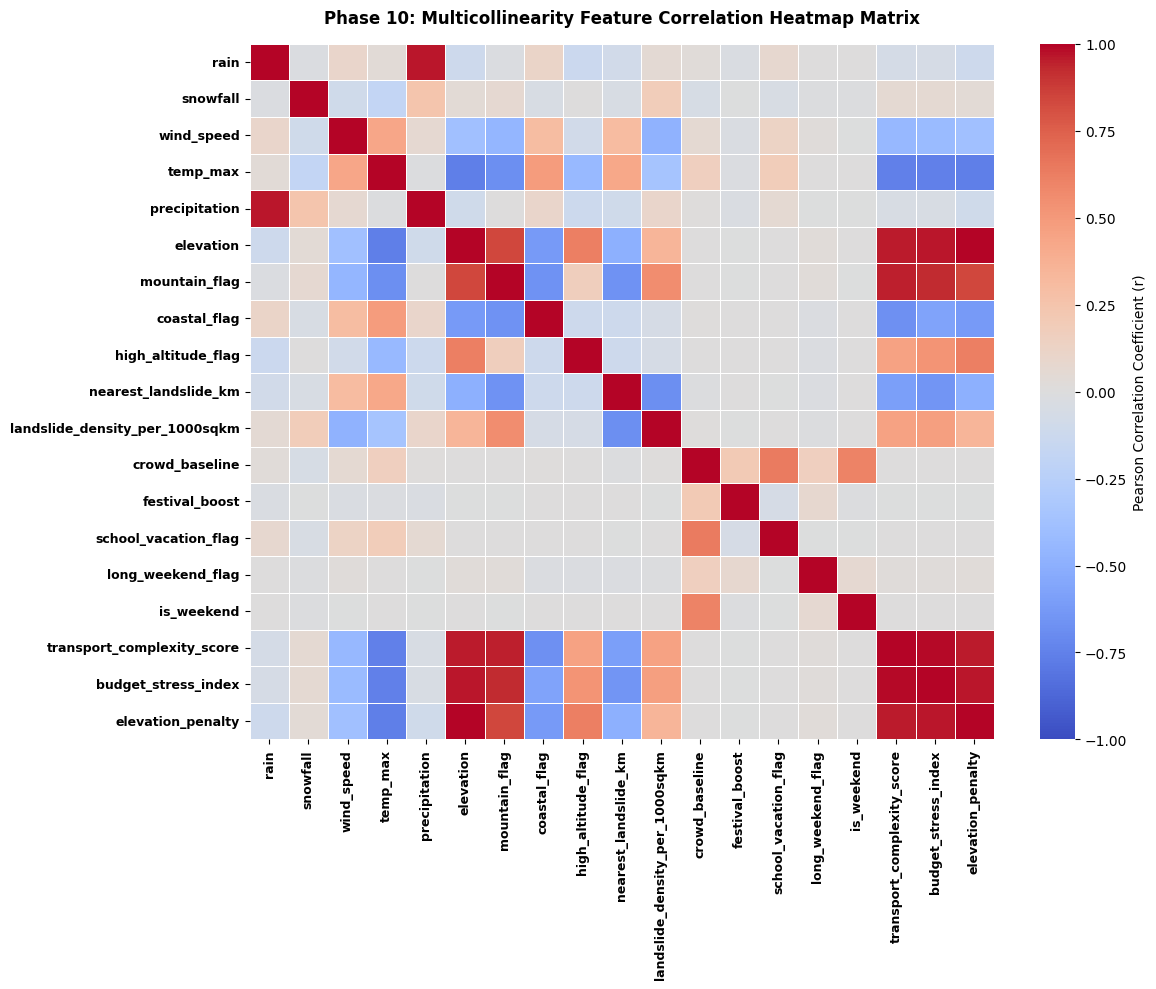

 ✅ Success: Multicollinearity Heatmap matrix graphic written to: 'ml_feature_correlation_matrix.png'


In [29]:
print("=====================================================================")
print("🏁 NOTEBOOK 08A CLOSING ENHANCEMENTS: STRUCTURAL CORRELATION AUDIT")
print("=====================================================================")

# 1. FIX 2: Generate and Export Feature Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
feature_corr_matrix = X.corr()

# Draw clean rectangular heatmap layout with crisp bounds
sns.heatmap(
    feature_corr_matrix, 
    cmap="coolwarm", 
    vmin=-1.0, 
    vmax=1.0, 
    annot=False, 
    linewidths=0.5, 
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
)
plt.xticks(fontsize=9, fontweight="bold", rotation=90)
plt.yticks(fontsize=9, fontweight="bold")
plt.title("Phase 10: Multicollinearity Feature Correlation Heatmap Matrix", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()

output_heatmap_png = "ml_feature_correlation_matrix.png"
plt.savefig(output_heatmap_png, dpi=300)
plt.show()
print(f" ✅ Success: Multicollinearity Heatmap matrix graphic written to: '{output_heatmap_png}'")

In [30]:
# 2. ADDITIONAL AUDIT: Compute and Save Target Correlation Rankings
corr_target = (
    df[feature_columns + ['overall_hazard_score']]
    .corr(numeric_only=True)['overall_hazard_score']
    .sort_values(ascending=False)
)

output_corr_csv = "target_feature_correlations.csv"
corr_target.to_frame(name="Pearson Correlation (r)").to_csv(output_corr_csv)
print(f" ✅ Success: Ground-truth target correlation weights exported to: '{output_corr_csv}'")

 ✅ Success: Ground-truth target correlation weights exported to: 'target_feature_correlations.csv'


In [31]:
# 3. FIX 3: Export Performance Leaderboard Report Matrix as Portfolio Evidence
output_report_csv = "model_performance_report.csv"
df_leaderboard.to_csv(output_report_csv, index=False)
print(f" ✅ Success: Performance leaderboard portfolio asset written to: '{output_report_csv}'")

print("\n--- TARGET VARIABLE (y) CORRELATION LEADERBOARD PREVIEW ---")
print(corr_target)
print("=====================================================================")
print("🚀 NOTEBOOK 08A OFFICIALLY PIPELINED, SAVED, AND CLOSED.")
print("=====================================================================")

 ✅ Success: Performance leaderboard portfolio asset written to: 'model_performance_report.csv'

--- TARGET VARIABLE (y) CORRELATION LEADERBOARD PREVIEW ---
overall_hazard_score              1.000000
budget_stress_index               0.661285
mountain_flag                     0.658934
transport_complexity_score        0.652268
elevation                         0.565839
elevation_penalty                 0.565839
crowd_baseline                    0.495448
precipitation                     0.453287
rain                              0.437186
landslide_density_per_1000sqkm    0.413690
school_vacation_flag              0.407200
is_weekend                        0.247679
high_altitude_flag                0.234165
snowfall                          0.112276
festival_boost                    0.090567
long_weekend_flag                 0.083814
wind_speed                       -0.139903
coastal_flag                     -0.303914
temp_max                         -0.403393
nearest_landslide_km       

In [32]:
print("=====================================================================")
print("🛡️ STRESS-TEST: LEAKAGE AUDIT & CHRONOLOGICAL CROSS-VALIDATION")
print("=====================================================================")

🛡️ STRESS-TEST: LEAKAGE AUDIT & CHRONOLOGICAL CROSS-VALIDATION


In [33]:
# 1. Define Strict Leakage-Free Raw Features
raw_feature_columns = [
    'rain', 'snowfall', 'wind_speed', 'temp_max', 'precipitation',
    'elevation', 'mountain_flag', 'coastal_flag', 'high_altitude_flag',
    'nearest_landslide_km', 'landslide_density_per_1000sqkm',
    'crowd_baseline', 'festival_boost', 'school_vacation_flag', 'long_weekend_flag', 'is_weekend'
]

In [34]:
# 2. Implement Strict Chronological Time-Based Split
df['date'] = pd.to_datetime(df['date'])

train_mask = df['date'] < '2025-01-01'
test_mask = df['date'] >= '2025-01-01'

X_train_chrono = df.loc[train_mask, raw_feature_columns].astype(float)
y_train_chrono = df.loc[train_mask, 'overall_hazard_score'].astype(float)

X_test_chrono = df.loc[test_mask, raw_feature_columns].astype(float)
y_test_chrono = df.loc[test_mask, 'overall_hazard_score'].astype(float)

In [35]:
# 3. Train Leakage-Free Chronological Models
rf_chrono = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_chrono.fit(X_train_chrono, y_train_chrono)
rf_chrono_preds = rf_chrono.predict(X_test_chrono)
rf_chrono_r2 = r2_score(y_test_chrono, rf_chrono_preds)

lr_chrono = LinearRegression()
lr_chrono.fit(X_train_chrono, y_train_chrono)
lr_chrono_preds = lr_chrono.predict(X_test_chrono)
lr_chrono_r2 = r2_score(y_test_chrono, lr_chrono_preds)

In [36]:
print(f" -> Chronological Train Window : 2021-2024 ({X_train_chrono.shape[0]} rows)")
print(f" -> Chronological Test Window  : 2025 ({X_test_chrono.shape[0]} rows)")
print(f" -> Number of Features Used    : {len(raw_feature_columns)} (Engineered Helpers Excluded)")
print("\n🏆 LEAKAGE-FREE CHRONOLOGICAL PERFORMANCE RESULTS:")
print(f" -> Linear Regression Chronological R² : {round(lr_chrono_r2, 4)}")
print(f" -> Random Forest Chronological R²     : {round(rf_chrono_r2, 4)}")

 -> Chronological Train Window : 2021-2024 (14610 rows)
 -> Chronological Test Window  : 2025 (3650 rows)
 -> Number of Features Used    : 16 (Engineered Helpers Excluded)

🏆 LEAKAGE-FREE CHRONOLOGICAL PERFORMANCE RESULTS:
 -> Linear Regression Chronological R² : 0.9718
 -> Random Forest Chronological R²     : 0.9967


In [37]:
# 4. Save this audit log for portfolio evidence
df_stress_test = pd.DataFrame({
    "Audit_Metric": ["Chrono_Train_Rows", "Chrono_Test_Rows", "Linear_Regression_Chrono_R2", "Random_Forest_Chrono_R2"],
    "Value": [X_train_chrono.shape[0], X_test_chrono.shape[0], lr_chrono_r2, rf_chrono_r2]
})
df_stress_test.to_csv("model_leakage_stress_test_report.csv", index=False)
print("\n ✅ Stress-test audit metrics successfully saved to 'model_leakage_stress_test_report.csv'")
print("=====================================================================")


 ✅ Stress-test audit metrics successfully saved to 'model_leakage_stress_test_report.csv'


In [38]:
import pandas as pd

# Load the saved performance leaderboard report from your directory
df_leaderboard_report = pd.read_csv("model_performance_report.csv")

print("=====================================================================")
print("📋 NOTEBOOK 08A: LEADERBOARD DATAFRAME COLUMNS")
print("=====================================================================")
print(df_leaderboard_report.columns.tolist())
print("\n--- ACTUAL TRANSCRIPT DATAFRAME ROW VALUES ---")
print(df_leaderboard_report)
print("=====================================================================")

📋 NOTEBOOK 08A: LEADERBOARD DATAFRAME COLUMNS
['Model Candidate', 'Test R² Score', 'Mean CV R² Score', 'CV R² Std Dev', 'Test MAE', 'Test RMSE']

--- ACTUAL TRANSCRIPT DATAFRAME ROW VALUES ---
              Model Candidate  Test R² Score  Mean CV R² Score  CV R² Std Dev  \
0           XGBoost Regressor         0.9988            0.9988         0.0002   
1     Random Forest Regressor         0.9978            0.9974         0.0004   
2  Linear Regression Baseline         0.9750            0.9603         0.0165   

   Test MAE  Test RMSE  
0    0.1303     0.2414  
1    0.1278     0.3370  
2    0.6159     1.1259  
